### Loading and identfying the names of the features used in training the model

In [2]:
import joblib
import pandas as pd

model = joblib.load(f'../models/Mugimba_best_model.pkl')
print(model.feature_names_in_)

['Pregnancies' 'Glucose' 'BloodPressure' 'SkinThickness' 'BMI'
 'DiabetesPedigreeFunction' 'Age']


Part C: Question 2: Loading the Model and Demonstrating Reuse (5 Marks)

In [7]:
import joblib
import pandas as pd

last_name = "Mugimba"
model = joblib.load(f'../models/{last_name}_best_model.pkl')

sample_data = pd.DataFrame({
    'Pregnancies': [6, 1, 8],
    'Glucose': [148, 85, 183],
    'BloodPressure': [72, 66, 64],
    'SkinThickness': [35, 29, 0],
    'BMI': [33.6, 26.6, 23.3],
    'DiabetesPedigreeFunction': [0.627, 0.351, 0.672],
    'Age': [50, 31, 32]
})

inferences = model.predict(sample_data)

print("Example Inferences:", inferences)

Example Inferences: [1 0 1]


# Evaluating the models confidence in inference

In [4]:

probs = model.predict_proba(sample_data)
print("Probability of being diabetic:", probs[:, 1])

Probability of being diabetic: [0.87948803 0.09165776 0.81239716]


Insight on Predicted Probabilities
The model returned the following probabilities of being diabetic for three sample patients:

Sample 1: 87.95% → Very High Risk
Sample 2: 9.17% → Very Low Risk
Sample 3: 81.24% → High Risk

Question 3: Deployment Architecture Design (10 Marks)
Design Description (Markdown)
Using Streamlit for simplicity:

Architecture: User accesses web app → inputs patient data via form → app loads model.pkl → predicts risk → displays result for example "High Risk").
Illustration: Browser (User) → Streamlit Server (loads model, processes input) → Prediction Output.
Script: See deployment/app.py 

## Question 1: Textual Dataset & NLP (10 Marks)

### Approach
- **Dataset**: Public medical abstracts corpus (Medical Abstracts TC Corpus) with ~11,550 entries on diseases.
- **Preprocessing**: Lowercase, remove non-alpha, stopwords.
- **NLP Task**: Word frequency analysis (insights: common terms like "patient", "treatment" indicate focus on clinical outcomes for patient intelligence).
- **Visualization**: Word cloud.

Textual Dataset Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11550 entries, 0 to 11549
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   condition_label   11550 non-null  int64 
 1   medical_abstract  11550 non-null  object
dtypes: int64(1), object(1)
memory usage: 180.6+ KB
None
   condition_label                                   medical_abstract
0                5  Tissue changes around loose prostheses. A cani...
1                1  Neuropeptide Y and neuron-specific enolase lev...
2                2  Sexually transmitted diseases of the colon, re...
3                1  Lipolytic factors associated with murine and h...
4                3  Does carotid restenosis predict an increased r...
Top 10 Frequent Words: [('patients', 22751), ('less', 5881), ('may', 4012), ('treatment', 3898), ('two', 3888), ('one', 3602), ('group', 3492), ('blood', 3485), ('disease', 3422), ('study', 3319)]


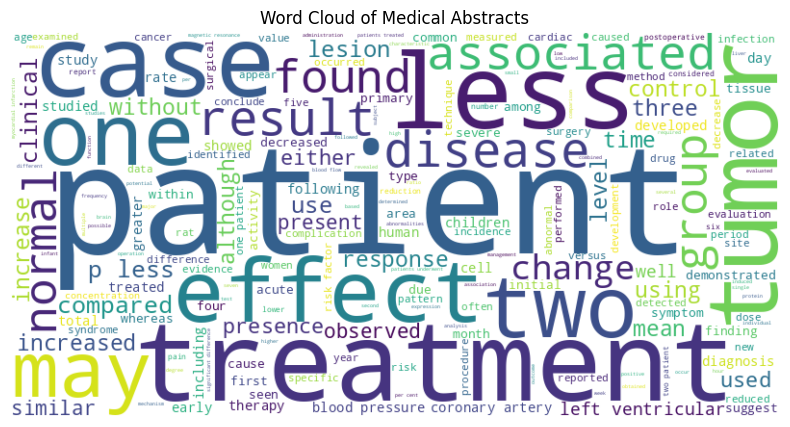

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Stopwords already downloaded in devcontainer
stop_words = set(stopwords.words('english'))

# Obtain textual dataset
text_url = "https://raw.githubusercontent.com/sebischair/Medical-Abstracts-TC-Corpus/main/medical_tc_train.csv"
df_text = pd.read_csv(text_url)
print("Textual Dataset Structure:")
print(df_text.info())
print(df_text.head())

# Saving raw data
df_text.to_csv('../data/raw_text.csv', index=False)

# Preprocess: Simple split (avoid NLTK tokenizer issue)
df_text['clean_text'] = df_text['medical_abstract'].apply(lambda x: ' '.join([word.lower() for word in str(x).split() if word.isalpha() and word.lower() not in stop_words]))

# NLP Task: Word Frequency (insights: frequent terms reveal key healthcare themes)
all_text = ' '.join(df_text['clean_text'])
word_freq = Counter(all_text.split())
print("Top 10 Frequent Words:", word_freq.most_common(10))

# Visualization using Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Medical Abstracts")
plt.show()
plt.savefig('../data/nlp_wordcloud.png')

Insights: Frequent 'blood' and 'treatment' terms align with diabetes monitoring, suggesting integration with structured model for better risk prediction.